# **Multi-Agent Reinforcement Learning**



---
## Nash Equilibrium (Theory)

A Nash Equilibrium (NE) represents a state where no player can improve their outcome by unilaterally changing their strategy. For our games, we'll focus on finding the mixed-strategy NE, where players choose their actions probabilistically.

### 1.1 Standard Medieval Warfare (Cavalry-Infantry-Archers)

In this tactical game, two generals face off. Cavalry beats Archers, Archers beat Infantry, and Infantry beats Cavalry. Given the standard payoff matrix:

| Player 1 | Cavalry | Infantry | Archers |
| :--- | :--: | :---: | :---: |
| **Cavalry** | 0, 0 | -1, 1 | 1, -1 |
| **Infantry**| 1, -1 | 0, 0 | -1, 1 |
| **Archers** | -1, 1 | 1, -1 | 0, 0 |

**Your Task:** Analytically derive the mixed-strategy Nash Equilibrium for this game. Show the steps for setting up the indifference equations for Player 1 and solving for Player 2's equilibrium strategy probabilities $(q_C, q_I, q_A)$. (Find the Mixed Nash equilibrium of the game).

### 1.2 Modified Medieval Warfare

Now, consider a modified game where the terrain alters the combat effectiveness. A Cavalry charge against Archers is absolutely devastating, but Archers have a stronger high-ground advantage against Infantry:

| Player 1 | Cavalry | Infantry | Archers |
| :--- | :--: | :---: | :---: |
| **Cavalry** | 0, 0 | -1, 1 | 3, -3 |
| **Infantry**| 1, -1 | 0, 0 | -2, 2 |
| **Archers** | -3, 3 | 2, -2 | 0, 0 |

**Your Task:** Like the previous one, derive the mixed-strategy Nash Equilibrium for this modified game. Show your work as you calculate the new probability distribution.


## Your answer

For both games, let

$$
q=(q_C,q_I,q_A)
$$

be Player 2's mixed strategy. Player 1 must be indifferent among all pure actions used with positive probability at a fully mixed equilibrium.

### 1.1 Standard game

Player 1's expected payoff from each pure action is

$$
u_C(q)=-q_I+q_A,
$$

$$
u_I(q)=q_C-q_A,
$$

$$
u_A(q)=-q_C+q_I.
$$

At a fully mixed equilibrium,

$$
-q_I+q_A=q_C-q_A=-q_C+q_I,
$$

with

$$
q_C+q_I+q_A=1.
$$

Solving gives

$$
q_C=q_I=q_A=\frac{1}{3}.
$$

The game is symmetric and zero-sum ($B=-A$), so Player 1 has the same equilibrium distribution:

$$
p^*=q^*=
\left(
\frac{1}{3},
\frac{1}{3},
\frac{1}{3}
\right).
$$

Each pure action has expected payoff $0$ against the opponent's equilibrium strategy, so the game value is

$$
v=0.
$$

### 1.2 Modified game

For the modified payoff matrix, Player 1's pure-action expected payoffs against $q$ are

$$
u_C(q)=-q_I+3q_A,
$$

$$
u_I(q)=q_C-2q_A,
$$

$$
u_A(q)=-3q_C+2q_I.
$$

Indifference requires

$$
-q_I+3q_A
=
q_C-2q_A
=
-3q_C+2q_I,
$$

with

$$
q_C+q_I+q_A=1.
$$

Because the payoff matrix is skew-symmetric, the equilibrium value is $0$. Thus the indifference equations may be written as

$$
-q_I+3q_A=0,
$$

$$
q_C-2q_A=0,
$$

$$
-3q_C+2q_I=0.
$$

Hence,

$$
q_I=3q_A,
\qquad
q_C=2q_A.
$$

Using normalization,

$$
2q_A+3q_A+q_A=1,
$$

so

$$
6q_A=1
$$

and therefore

$$
q_A=\frac{1}{6}.
$$

Thus,

$$
q_C=\frac{1}{3},
\qquad
q_I=\frac{1}{2},
\qquad
q_A=\frac{1}{6}.
$$

Again, by symmetry,

$$
p^*=q^*=
\left(
\frac{1}{3},
\frac{1}{2},
\frac{1}{6}
\right),
\qquad
v=0.
$$

Changing only the payoff magnitudes changes the indifference equations. The cyclic win/loss ordering is unchanged, but the probabilities needed to make the opponent indifferent are no longer equal, so the mixed Nash equilibrium changes.


## Problem 2: Learning by Observation - Fictitious Play (Implementation)

Fictitious Play is an intuitive learning algorithm where each agent models its opponent as playing a stationary strategy defined by the historical frequency of their past actions. The agent then plays a **best response** to this belief.

### 2.1 Implementation

**Your Task:** Implement the `simulate_fictitious_play` function below. It should take the payoff matrices for both players and the number of iterations as input. At each step, each player should choose the action that maximizes their expected payoff given the history of the opponent's plays.

**Algorithm:** At each time step $t > 0$, Player $i$ forms a belief that their opponent ($-i$) will play each action $a'$ with a probability equal to its historical frequency. The agent then chooses an action $a_i^*$ that is a best response to this belief.

Let $C_{t-1}(a_{-i})$ be the count of times opponent $-i$ has played action $a_{-i}$ up to step $t-1$. Player $i$'s best response is:
$$a_{i,t}^* = \arg\max_{a_i \in A_i} \sum_{a_{-i} \in A_{-i}} u_i(a_i, a_{-i}) \cdot \frac{C_{t-1}(a_{-i})}{t-1}$$

**Note on Tie-Breaking:** If multiple actions yield the same maximal expected payoff, your agent should choose one of these best responses uniformly at random.


**Your Task:**
1.  Run your simulation for **1,000,000 iterations** on both the **standard** and **modified** RSP games.
2.  Generate two plots, one for each game. Each plot should show the evolution of Players action frequencies over time and include horizontal lines indicating the theoretical NE probabilities you calculated in Problem 1.
3.  **Analyze your results:** Do the action frequencies converge? If so, do they converge to the Nash Equilibrium? Explain the observed behavior.


Running Standard Fictitious Play...
Running Modified Fictitious Play...


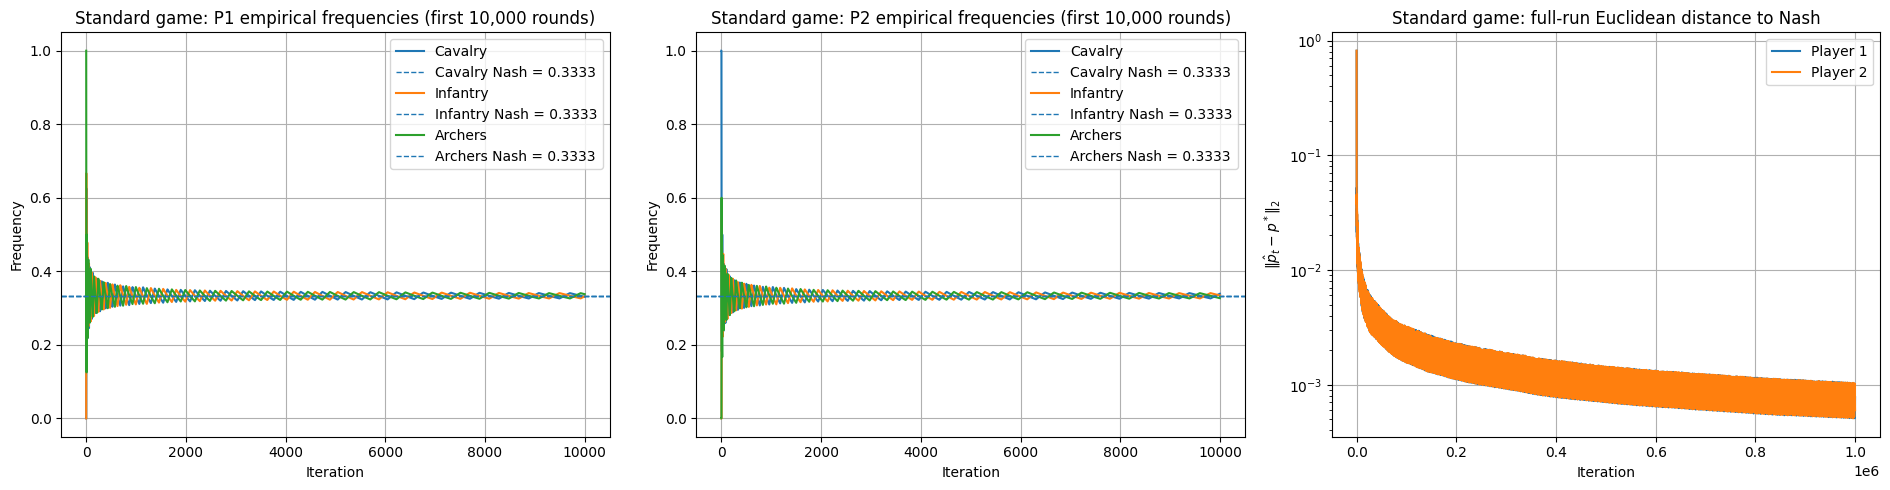

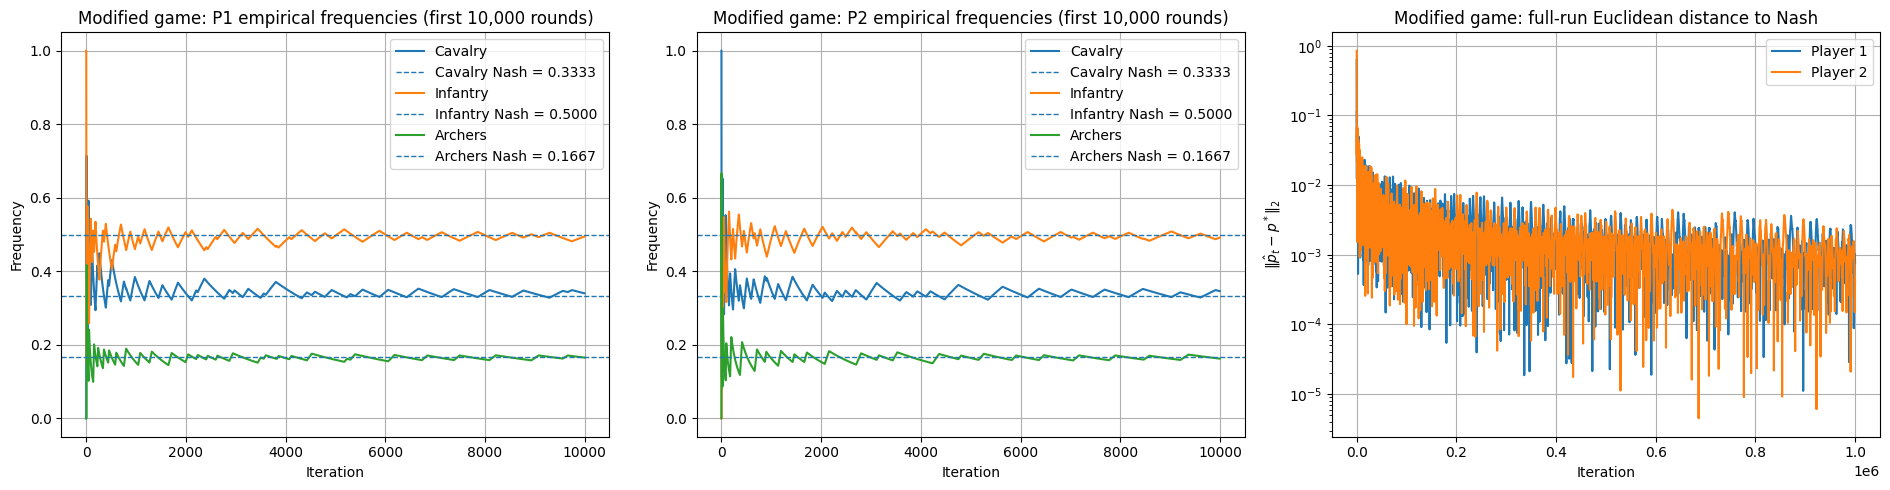

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Action order used throughout the notebook:
# 0 = Cavalry, 1 = Infantry, 2 = Archers
ACTION_NAMES = ["Cavalry", "Infantry", "Archers"]


def _validate_bimatrix_game(payoff_A, payoff_B):
    """Convert the payoff matrices to arrays and validate their compatibility."""
    A = np.asarray(payoff_A, dtype=float)
    B = np.asarray(payoff_B, dtype=float)

    if A.ndim != 2 or B.ndim != 2:
        raise ValueError("Both payoff matrices must be two-dimensional.")
    if A.shape != B.shape:
        raise ValueError(
            f"Payoff matrices must have the same shape; got {A.shape} and {B.shape}."
        )
    if A.shape[0] == 0 or A.shape[1] == 0:
        raise ValueError("The game must contain at least one action for each player.")
    if not np.all(np.isfinite(A)) or not np.all(np.isfinite(B)):
        raise ValueError("Payoff matrices must contain only finite values.")

    return A, B


def _uniform_argmax(values, rng, atol=1e-12):
    """
    Select uniformly from all numerically tied maximizers.

    Using a tolerance rather than np.argmax avoids a deterministic first-index
    bias when several actions are best responses.
    """
    values = np.asarray(values, dtype=float)
    max_value = np.max(values)
    best = np.flatnonzero(values >= max_value - atol)
    return int(best[rng.integers(best.size)])


def _plot_indices(n, max_points=20_000):
    """Downsample only for plotting; all simulation statistics use full histories."""
    step = max(1, int(np.ceil(n / max_points)))
    return np.arange(0, n, step)


def simulate_fictitious_play(payoff_A, payoff_B, iterations, seed=2026):
    """
    Simulate empirical-belief Fictitious Play for two players.

    Player 1 chooses rows and Player 2 chooses columns. At every round after
    initialization, each player best-responds to the opponent's empirical
    action-frequency distribution. Tied best responses are sampled uniformly.

    Parameters
    ----------
    payoff_A : array_like, shape (m, n)
        Player 1 payoff matrix.
    payoff_B : array_like, shape (m, n)
        Player 2 payoff matrix.
    iterations : int
        Number of realized joint-action rounds, including initialization.
    seed : int or None
        Seed for reproducible initialization and tie-breaking.

    Returns
    -------
    p1_freq_history : ndarray, shape (iterations, m)
        Player 1 empirical action frequencies after every realized round.
    p2_freq_history : ndarray, shape (iterations, n)
        Player 2 empirical action frequencies after every realized round.
    """
    A, B = _validate_bimatrix_game(payoff_A, payoff_B)

    if not isinstance(iterations, (int, np.integer)) or iterations <= 0:
        raise ValueError("iterations must be a positive integer.")

    num_actions_p1, num_actions_p2 = A.shape
    rng = np.random.default_rng(seed)

    p1_counts = np.zeros(num_actions_p1, dtype=np.int64)
    p2_counts = np.zeros(num_actions_p2, dtype=np.int64)

    p1_freq_history = np.empty((iterations, num_actions_p1), dtype=float)
    p2_freq_history = np.empty((iterations, num_actions_p2), dtype=float)

    # Initialize with one realized action per player. This makes the first
    # empirical belief well-defined and avoids a zero denominator.
    p1_action = int(rng.integers(num_actions_p1))
    p2_action = int(rng.integers(num_actions_p2))
    p1_counts[p1_action] += 1
    p2_counts[p2_action] += 1

    p1_freq_history[0] = p1_counts
    p2_freq_history[0] = p2_counts

    for t in range(1, iterations):
        # The denominator t is common to every pure-action expected payoff,
        # so counts can be used directly when computing the argmax. This is
        # exactly equivalent to best-responding to counts / t and is faster.
        p1_expected_by_action = A @ p2_counts
        p2_expected_by_action = p1_counts @ B

        p1_action = _uniform_argmax(p1_expected_by_action, rng)
        p2_action = _uniform_argmax(p2_expected_by_action, rng)

        p1_counts[p1_action] += 1
        p2_counts[p2_action] += 1

        inv_rounds = 1.0 / (t + 1)
        p1_freq_history[t] = p1_counts * inv_rounds
        p2_freq_history[t] = p2_counts * inv_rounds

    return p1_freq_history, p2_freq_history


# ==========================================
# PAYOFF MATRICES AND THEORETICAL EQUILIBRIA
# ==========================================
A_std = np.array([
    [ 0, -1,  1],
    [ 1,  0, -1],
    [-1,  1,  0],
], dtype=float)
B_std = -A_std

A_mod = np.array([
    [ 0, -1,  3],
    [ 1,  0, -2],
    [-3,  2,  0],
], dtype=float)
B_mod = -A_mod

nash_std = np.array([1/3, 1/3, 1/3], dtype=float)
nash_mod = np.array([1/3, 1/2, 1/6], dtype=float)

# Verify the indifference conditions and zero game value numerically.
assert np.allclose(A_std @ nash_std, 0.0)
assert np.allclose(nash_std @ B_std, 0.0)
assert np.allclose(A_mod @ nash_mod, 0.0)
assert np.allclose(nash_mod @ B_mod, 0.0)


# ==========================================
# RUN FICTITIOUS PLAY
# ==========================================
iterations = 1_000_000

print("Running Standard Fictitious Play...")
p1_freq_history_std, p2_freq_history_std = simulate_fictitious_play(
    A_std, B_std, iterations, seed=2026
)

print("Running Modified Fictitious Play...")
p1_freq_history_mod, p2_freq_history_mod = simulate_fictitious_play(
    A_mod, B_mod, iterations, seed=2027
)


def plot_fictitious_play_game(p1_hist, p2_hist, nash, title, display_horizon=10_000):
    """
    Plot the informative early transient while keeping the simulation itself
    at the full requested horizon.

    With one million empirical-frequency updates, a linear full-horizon plot
    visually compresses the best-response oscillations into an almost flat
    line. The first 10,000 rounds reveal the dynamics clearly; final/full-run
    convergence is still reported numerically below.
    """
    horizon = min(display_horizon, len(p1_hist))
    plot_idx = np.arange(horizon)

    # Distance is useful over the complete one-million-round run.
    full_idx = _plot_indices(len(p1_hist))
    p1_dist = np.linalg.norm(p1_hist - nash, axis=1)
    p2_dist = np.linalg.norm(p2_hist - nash, axis=1)

    fig, axes = plt.subplots(1, 3, figsize=(19, 5))

    for a, name in enumerate(ACTION_NAMES):
        axes[0].plot(plot_idx, p1_hist[:horizon, a], label=name)
        axes[0].axhline(
            nash[a], linestyle="--", linewidth=1,
            label=f"{name} Nash = {nash[a]:.4f}"
        )
    axes[0].set_title(
        f"{title}: P1 empirical frequencies (first {horizon:,} rounds)"
    )
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(True)
    axes[0].legend()

    for a, name in enumerate(ACTION_NAMES):
        axes[1].plot(plot_idx, p2_hist[:horizon, a], label=name)
        axes[1].axhline(
            nash[a], linestyle="--", linewidth=1,
            label=f"{name} Nash = {nash[a]:.4f}"
        )
    axes[1].set_title(
        f"{title}: P2 empirical frequencies (first {horizon:,} rounds)"
    )
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(
        full_idx, np.maximum(p1_dist[full_idx], 1e-16), label="Player 1"
    )
    axes[2].plot(
        full_idx, np.maximum(p2_dist[full_idx], 1e-16), label="Player 2"
    )
    axes[2].set_yscale("log")
    axes[2].set_title(f"{title}: full-run Euclidean distance to Nash")
    axes[2].set_xlabel("Iteration")
    axes[2].set_ylabel(r"$\|\hat p_t-p^*\|_2$")
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()


plot_fictitious_play_game(
    p1_freq_history_std, p2_freq_history_std, nash_std, "Standard game"
)
plot_fictitious_play_game(
    p1_freq_history_mod, p2_freq_history_mod, nash_mod, "Modified game"
)


In [2]:
# Quantitative summaries for the fictitious-play runs.
def summarize_fp(name, p1_hist, p2_hist, nash):
    p1_final = p1_hist[-1]
    p2_final = p2_hist[-1]
    p1_dist = np.linalg.norm(p1_final - nash)
    p2_dist = np.linalg.norm(p2_final - nash)

    print(f"\n{name}")
    print("-" * len(name))
    print("Theoretical Nash:", np.array2string(nash, precision=6))
    print("P1 final empirical strategy:", np.array2string(p1_final, precision=6))
    print("P2 final empirical strategy:", np.array2string(p2_final, precision=6))
    print(f"P1 final L2 distance to Nash: {p1_dist:.8f}")
    print(f"P2 final L2 distance to Nash: {p2_dist:.8f}")


summarize_fp(
    "Standard fictitious play",
    p1_freq_history_std,
    p2_freq_history_std,
    nash_std,
)
summarize_fp(
    "Modified fictitious play",
    p1_freq_history_mod,
    p2_freq_history_mod,
    nash_mod,
)



Standard fictitious play
------------------------
Theoretical Nash: [0.333333 0.333333 0.333333]
P1 final empirical strategy: [0.333845 0.333438 0.332717]
P2 final empirical strategy: [0.333083 0.33311  0.333807]
P1 final L2 distance to Nash: 0.00080785
P2 final L2 distance to Nash: 0.00058043

Modified fictitious play
------------------------
Theoretical Nash: [0.333333 0.5      0.166667]
P1 final empirical strategy: [0.332902 0.499847 0.167251]
P2 final empirical strategy: [0.333284 0.499733 0.166983]
P1 final L2 distance to Nash: 0.00074223
P2 final L2 distance to Nash: 0.00041688


---
## Problem 3: Fictitious Play with Exploration (Implementation)

Our Fictitious Play agent is purely exploitative. In Reinforcement Learning, we know the importance of the **exploration-exploitation tradeoff**. Let's create an $\epsilon$-greedy version of Fictitious Play.

### 3.1 Implementation

**Your Task:** Create a new function, `simulate_epsilon_greedy_fp`. This function should be similar to your Fictitious Play implementation but include an `epsilon` parameter. At each step, with probability `epsilon`, the agent should choose a random action (explore). With probability `1-epsilon`, it should play the best response (exploit).



**Your Task:**
1.  Run the `simulate_epsilon_greedy_fp` function on the **modified** RSP game for **1,000,000 iterations** with three different `epsilon` values: `0.01`, `0.1`, and `0.3`.
2.  Plot the results for each simulation.
3.  **Analyze your results:** How does `epsilon` affect the learning dynamics? Does the agent's strategy still converge to the NE? If not, to what does it converge? Discuss the impact of exploration in this multi-agent context.


### Plotting note

The experiments below still run for **1,000,000 rounds**. For visualization, the frequency panels show the first **10,000 rounds**, because plotting one million cumulative empirical-frequency points on a linear x-axis compresses the oscillatory transient into an almost flat line. The payoff panel additionally omits only the first 20 points **from the display** so that a single extreme payoff caused by one-hot initialization does not determine the entire y-axis. All one million samples remain in the stored histories and reported statistics.


Plots show the first 10,000 rounds so the transient best-response oscillations remain visible. The payoff panel starts at round 20 only for display because a single one-hot initialization payoff can otherwise dominate the y-axis. No samples are removed from the simulation or statistics.

Running epsilon-greedy fictitious play with epsilon=0.01...
P1 final empirical strategy: [0.334749 0.498897 0.166354]
P2 final empirical strategy: [0.333467 0.499551 0.166982]
P1 L2 distance to unperturbed Nash: 0.00182167
P2 L2 distance to unperturbed Nash: 0.00056471
P1 empirical-joint expected payoff over last 100,000 rounds: mean=-0.00000008, std=0.00000240
P1 realized one-step payoff over last 100,000 rounds: mean=+0.00363000, std=1.50990623, var=2.27981682
Exploratory-mixture formula if exploitation settles on x: (1-epsilon)*x + epsilon*Uniform; Uniform = [0.333333 0.333333 0.333333]


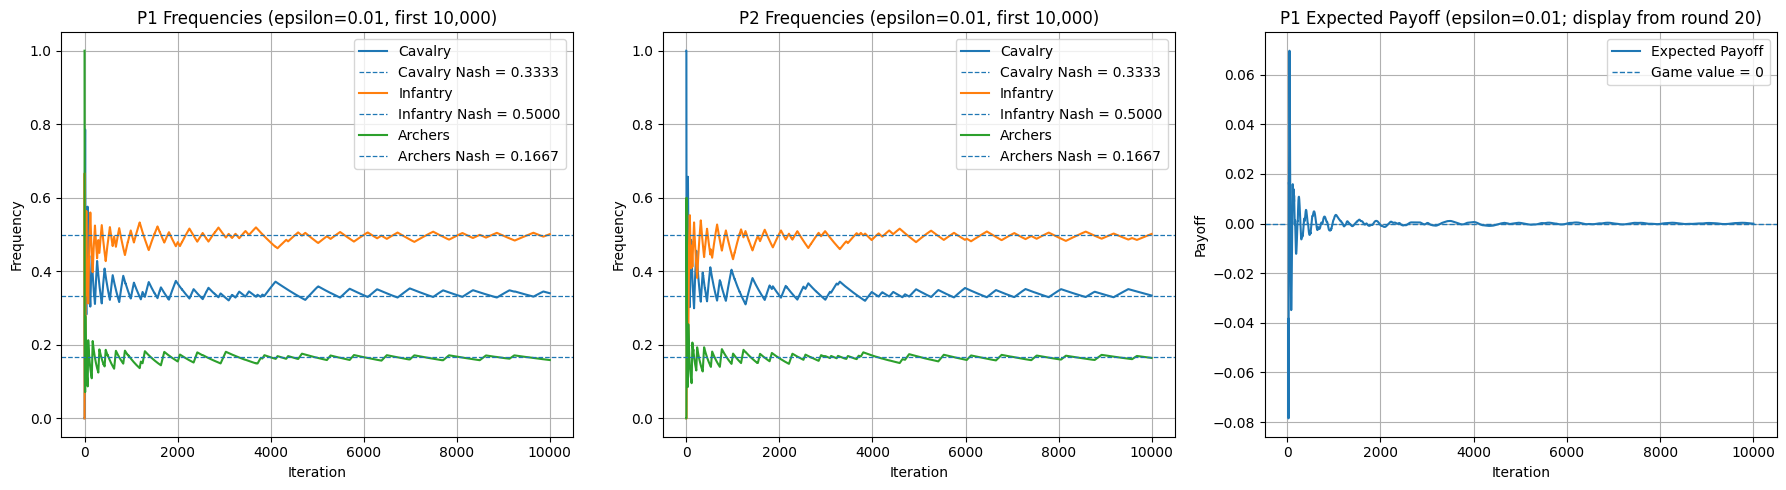


Running epsilon-greedy fictitious play with epsilon=0.1...
P1 final empirical strategy: [0.335097 0.49838  0.166523]
P2 final empirical strategy: [0.334327 0.499252 0.166421]
P1 L2 distance to unperturbed Nash: 0.00239907
P2 L2 distance to unperturbed Nash: 0.00126777
P1 empirical-joint expected payoff over last 100,000 rounds: mean=+0.00000010, std=0.00000235
P1 realized one-step payoff over last 100,000 rounds: mean=-0.01147000, std=1.44792211, var=2.09647844
Exploratory-mixture formula if exploitation settles on x: (1-epsilon)*x + epsilon*Uniform; Uniform = [0.333333 0.333333 0.333333]


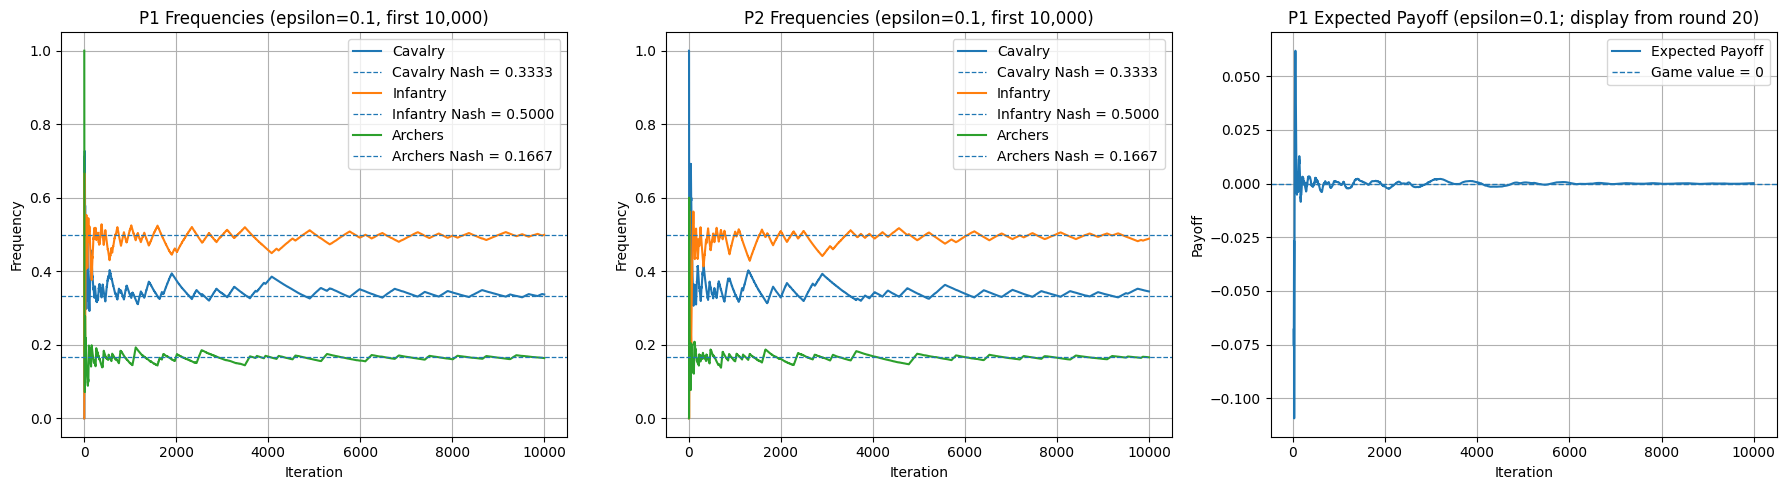


Running epsilon-greedy fictitious play with epsilon=0.3...
P1 final empirical strategy: [0.334378 0.498904 0.166718]
P2 final empirical strategy: [0.333985 0.499719 0.166296]
P1 L2 distance to unperturbed Nash: 0.00151499
P2 L2 distance to unperturbed Nash: 0.00080064
P1 empirical-joint expected payoff over last 100,000 rounds: mean=+0.00000035, std=0.00000133
P1 realized one-step payoff over last 100,000 rounds: mean=+0.00320000, std=1.42484026, var=2.03016976
Exploratory-mixture formula if exploitation settles on x: (1-epsilon)*x + epsilon*Uniform; Uniform = [0.333333 0.333333 0.333333]


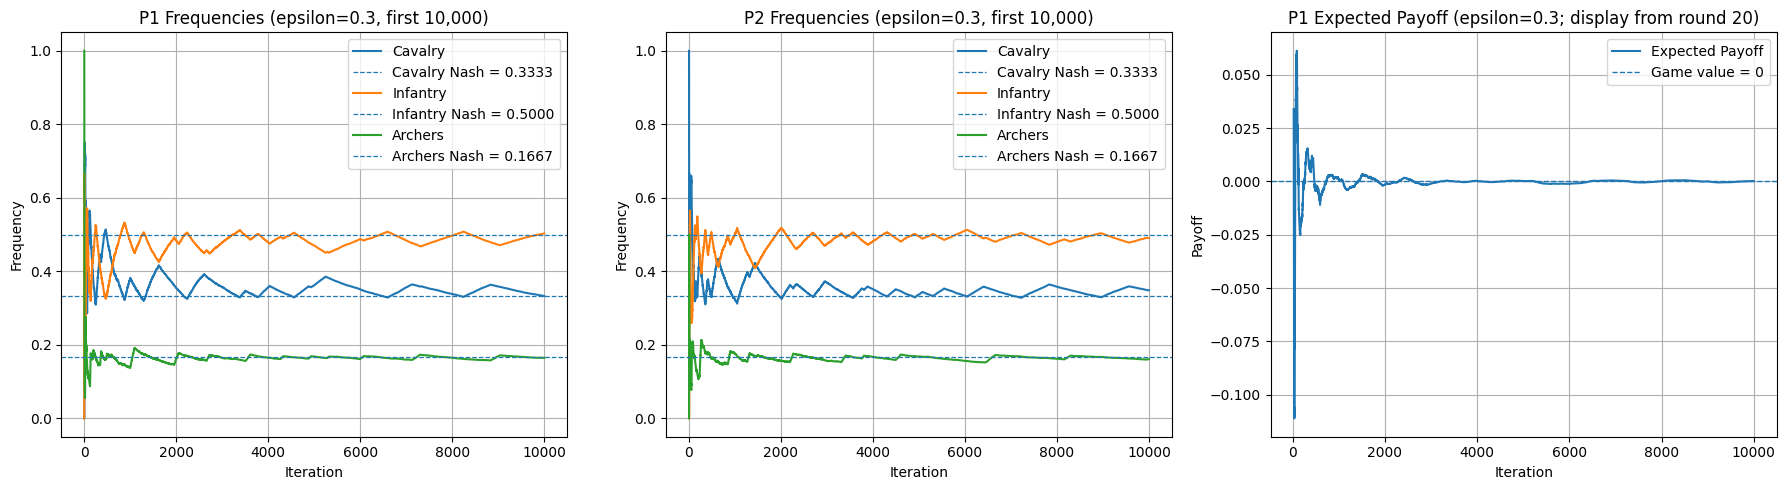

In [3]:
import numpy as np
import matplotlib.pyplot as plt


def simulate_epsilon_greedy_fp(A, B, iterations, epsilon, seed=2026):
    """
    Simulate epsilon-greedy empirical-belief Fictitious Play.

    At each round, the currently selected joint action is realized first.
    Counts and empirical beliefs are then updated and recorded. The next
    actions are chosen independently by epsilon-greedy best response to those
    empirical beliefs.

    Each player independently:
      * explores uniformly with probability epsilon;
      * otherwise plays a uniformly tie-broken best response.

    Returns
    -------
    p1_freq_history : ndarray, shape (iterations, m)
        Player 1 empirical action frequencies after every realized round.
    p2_freq_history : ndarray, shape (iterations, n)
        Player 2 empirical action frequencies after every realized round.
    p1_expected_payoff_history : ndarray, shape (iterations,)
        Expected P1 payoff p1_freq_t^T A p2_freq_t under the empirical product
        strategy at every recorded round, as required by the assignment.
    p1_realized_payoff_history : ndarray, shape (iterations,)
        Actual one-step P1 payoff A[a1_t, a2_t]. This is kept separately so
        payoff variance is measured from realized rewards rather than from the
        increasingly smoothed empirical-product payoff trace.
    """
    A, B = _validate_bimatrix_game(A, B)

    if not isinstance(iterations, (int, np.integer)) or iterations <= 0:
        raise ValueError("iterations must be a positive integer.")
    if not (0.0 <= epsilon <= 1.0):
        raise ValueError("epsilon must lie in [0, 1].")

    num_actions_p1, num_actions_p2 = A.shape
    rng = np.random.default_rng(seed)

    p1_counts = np.zeros(num_actions_p1, dtype=np.int64)
    p2_counts = np.zeros(num_actions_p2, dtype=np.int64)

    p1_freq_history = np.empty((iterations, num_actions_p1), dtype=float)
    p2_freq_history = np.empty((iterations, num_actions_p2), dtype=float)
    p1_expected_payoff_history = np.empty(iterations, dtype=float)
    p1_realized_payoff_history = np.empty(iterations, dtype=float)

    # Initial realized actions ensure a nonempty empirical history.
    p1_action = int(rng.integers(num_actions_p1))
    p2_action = int(rng.integers(num_actions_p2))

    for t in range(iterations):
        # 1) Realize the currently selected actions and store the unsmoothed
        #    one-step payoff before changing either action.
        p1_realized_payoff_history[t] = A[p1_action, p2_action]
        p1_counts[p1_action] += 1
        p2_counts[p2_action] += 1

        # 2) Form and record the current empirical beliefs.
        inv_rounds = 1.0 / (t + 1)
        p1_freq = p1_counts * inv_rounds
        p2_freq = p2_counts * inv_rounds
        p1_freq_history[t] = p1_freq
        p2_freq_history[t] = p2_freq

        # 3) Required expected-payoff trace under the empirical product
        #    strategy. This is NOT used as the realized-payoff variance.
        p1_expected_payoff_history[t] = float(p1_freq @ A @ p2_freq)

        # The final history row already contains the final empirical
        # frequencies, so no next action is needed after the last round.
        if t == iterations - 1:
            break

        # Counts and normalized frequencies induce the same argmax because the
        # normalizing denominator is common to every pure action.
        p1_expected_by_action = A @ p2_counts
        p2_expected_by_action = p1_counts @ B

        # 4) Independent epsilon-greedy action selection for the next round.
        if rng.random() < epsilon:
            p1_action = int(rng.integers(num_actions_p1))
        else:
            p1_action = _uniform_argmax(p1_expected_by_action, rng)

        if rng.random() < epsilon:
            p2_action = int(rng.integers(num_actions_p2))
        else:
            p2_action = _uniform_argmax(p2_expected_by_action, rng)

    # Basic consistency checks. The last row must represent the final counts.
    assert np.allclose(p1_freq_history.sum(axis=1), 1.0)
    assert np.allclose(p2_freq_history.sum(axis=1), 1.0)

    return (
        p1_freq_history,
        p2_freq_history,
        p1_expected_payoff_history,
        p1_realized_payoff_history,
    )


# Modified game matrices are defined in the fictitious-play cell above.
iterations = 1_000_000
epss = [0.01, 0.1, 0.3]
tail_window = 100_000
base_seed = 2026

epsilon_summaries = {}

# Visualization settings only. The simulation and all reported statistics still
# use the full 1,000,000 rounds.
plot_horizon = min(10_000, iterations)
payoff_plot_burn_in = min(20, max(0, plot_horizon - 1))

print(
    f"Plots show the first {plot_horizon:,} rounds so the transient "
    "best-response oscillations remain visible. "
    f"The payoff panel starts at round {payoff_plot_burn_in} only for display "
    "because a single one-hot initialization payoff can otherwise dominate "
    "the y-axis. No samples are removed from the simulation or statistics."
)

for epsilon in epss:
    print(f"\nRunning epsilon-greedy fictitious play with epsilon={epsilon}...")

    (
        p1_freq_history,
        p2_freq_history,
        p1_expected_payoff_history,
        p1_realized_payoff_history,
    ) = simulate_epsilon_greedy_fp(
        A_mod, B_mod, iterations, epsilon, seed=base_seed
    )

    p1_final = p1_freq_history[-1]
    p2_final = p2_freq_history[-1]
    p1_dist = np.linalg.norm(p1_final - nash_mod)
    p2_dist = np.linalg.norm(p2_final - nash_mod)

    tail = min(tail_window, iterations)

    # The expected-payoff trace is the assignment-requested empirical-joint
    # quantity. Realized one-step rewards are used for the payoff-variance
    # diagnostic requested in the comparison question.
    tail_expected_mean = float(np.mean(p1_expected_payoff_history[-tail:]))
    tail_expected_std = float(np.std(p1_expected_payoff_history[-tail:]))
    tail_realized_mean = float(np.mean(p1_realized_payoff_history[-tail:]))
    tail_realized_std = float(np.std(p1_realized_payoff_history[-tail:]))
    tail_realized_var = float(np.var(p1_realized_payoff_history[-tail:]))

    # General exploratory-mixture identity:
    # if the exploitative component settles on a fixed distribution x, then
    # the realized action distribution is (1-epsilon) * x + epsilon * Uniform.
    # We deliberately do NOT substitute x = Nash: fictitious play selects
    # changing best responses, so that substitution is not generally justified.
    num_actions = A_mod.shape[0]
    uniform_exploration = np.full(num_actions, 1.0 / num_actions)

    epsilon_summaries[epsilon] = {
        "p1_final": p1_final.copy(),
        "p2_final": p2_final.copy(),
        "p1_dist_to_nash": p1_dist,
        "p2_dist_to_nash": p2_dist,
        "tail_expected_mean": tail_expected_mean,
        "tail_expected_std": tail_expected_std,
        "tail_realized_mean": tail_realized_mean,
        "tail_realized_std": tail_realized_std,
        "tail_realized_var": tail_realized_var,
        "uniform_exploration": uniform_exploration.copy(),
    }

    print("P1 final empirical strategy:",
          np.array2string(p1_final, precision=6))
    print("P2 final empirical strategy:",
          np.array2string(p2_final, precision=6))
    print(f"P1 L2 distance to unperturbed Nash: {p1_dist:.8f}")
    print(f"P2 L2 distance to unperturbed Nash: {p2_dist:.8f}")
    print(
        f"P1 empirical-joint expected payoff over last {tail:,} rounds: "
        f"mean={tail_expected_mean:+.8f}, std={tail_expected_std:.8f}"
    )
    print(
        f"P1 realized one-step payoff over last {tail:,} rounds: "
        f"mean={tail_realized_mean:+.8f}, std={tail_realized_std:.8f}, "
        f"var={tail_realized_var:.8f}"
    )
    print(
        "Exploratory-mixture formula if exploitation settles on x: "
        "(1-epsilon)*x + epsilon*Uniform; Uniform =",
        np.array2string(uniform_exploration, precision=6),
    )

    # ----------------------------------------------------------
    # REFERENCE-STYLE TRANSIENT PLOTS
    # ----------------------------------------------------------
    # The assignment requires a 1,000,000-round run, but plotting all one
    # million empirical averages on a linear x-axis makes the learning
    # dynamics look artificially flat. Plot the first 10,000 rounds, matching
    # the informative scale of the reference figure, while retaining all
    # million rounds for final statistics.
    plot_idx = np.arange(plot_horizon)
    payoff_idx = np.arange(payoff_plot_burn_in, plot_horizon)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for a, name in enumerate(ACTION_NAMES):
        axes[0].plot(
            plot_idx, p1_freq_history[:plot_horizon, a], label=name
        )
        axes[0].axhline(
            nash_mod[a], linestyle="--", linewidth=0.9,
            label=f"{name} Nash = {nash_mod[a]:.4f}"
        )
    axes[0].set_title(
        f"P1 Frequencies (epsilon={epsilon}, first {plot_horizon:,})"
    )
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(True)
    axes[0].legend()

    for a, name in enumerate(ACTION_NAMES):
        axes[1].plot(
            plot_idx, p2_freq_history[:plot_horizon, a], label=name
        )
        axes[1].axhline(
            nash_mod[a], linestyle="--", linewidth=0.9,
            label=f"{name} Nash = {nash_mod[a]:.4f}"
        )
    axes[1].set_title(
        f"P2 Frequencies (epsilon={epsilon}, first {plot_horizon:,})"
    )
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(True)
    axes[1].legend()

    # Use the same expected-payoff quantity required by the assignment.
    # Only the first few points are omitted from THIS DISPLAY because with
    # one-hot initialization the first empirical-product payoff can be an
    # extreme matrix entry (e.g. -3), which crushes all later oscillations
    # against zero. The full trace remains stored and used in statistics.
    axes[2].plot(
        payoff_idx,
        p1_expected_payoff_history[payoff_idx],
        label="Expected Payoff",
    )
    axes[2].axhline(
        0.0, linestyle="--", linewidth=1, label="Game value = 0"
    )
    axes[2].set_title(
        f"P1 Expected Payoff (epsilon={epsilon}; display from round "
        f"{payoff_plot_burn_in})"
    )
    axes[2].set_xlabel("Iteration")
    axes[2].set_ylabel("Payoff")
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()


In [4]:
# Compact comparison table after all epsilon-greedy runs.
# Distances are to the unperturbed Nash equilibrium. Payoff variability is
# reported from realized one-step rewards, not from the smoothed expected-payoff
# trace.
print(
    "\nColumns: epsilon | P1 dist | P2 dist | "
    f"tail-{tail_window:,} expected mean | realized mean | realized std | realized var"
)
for epsilon in epss:
    s = epsilon_summaries[epsilon]
    print(
        f"{epsilon:>5.2f} | "
        f"{s['p1_dist_to_nash']:.8f} | "
        f"{s['p2_dist_to_nash']:.8f} | "
        f"{s['tail_expected_mean']:+.8f} | "
        f"{s['tail_realized_mean']:+.8f} | "
        f"{s['tail_realized_std']:.8f} | "
        f"{s['tail_realized_var']:.8f}"
    )

print(
    "\nExploratory-mixture identity: if the exploitative component converges "
    "to x, the realized distribution is (1-epsilon)*x + epsilon*Uniform. "
    "No x=Nash substitution is assumed here."
)



Columns: epsilon | P1 dist | P2 dist | tail-100,000 expected mean | realized mean | realized std | realized var
 0.01 | 0.00182167 | 0.00056471 | -0.00000008 | +0.00363000 | 1.50990623 | 2.27981682
 0.10 | 0.00239907 | 0.00126777 | +0.00000010 | -0.01147000 | 1.44792211 | 2.09647844
 0.30 | 0.00151499 | 0.00080064 | +0.00000035 | +0.00320000 | 1.42484026 | 2.03016976

Exploratory-mixture identity: if the exploitative component converges to x, the realized distribution is (1-epsilon)*x + epsilon*Uniform. No x=Nash substitution is assumed here.


### Algorithm

Regret Matching proceeds in three main steps.

#### 1. Regret Update

Suppose Player $i$ played action $a_i$ while the opponent played action $a_{-i}$. For every possible action $s \in A_i$, update the cumulative regret as

$$
R_t(s) = R_{t-1}(s) + u_i(s, a_{-i}) - u_i(a_i, a_{-i}).
$$

where

- $R_t(s)$ is the cumulative regret for not choosing action $s$.
- $u_i(s, a_{-i})$ is the payoff that would have been received by playing $s$.
- $u_i(a_i, a_{-i})$ is the payoff actually received.

#### 2. Strategy Update

Let the positive regret be

$$
R_t^{+}(s) = \max(0, R_t(s)).
$$

The probability of selecting action $s$ in the next round is

$$
p_{t+1}(s)
=
\frac{R_t^{+}(s)}
{\sum_{s' \in A_i} R_t^{+}(s')}.
$$

If

$$
\sum_{s' \in A_i} R_t^{+}(s') = 0,
$$

then choose uniformly at random among all actions.

#### 3. Total Regret Tracking

To verify that the algorithm is working correctly, also track the **sum of Player 1's positive cumulative regrets** after each iteration.

For a no-regret algorithm, the average regret should approach zero as the number of iterations increases.


Running regret matching on the modified game...


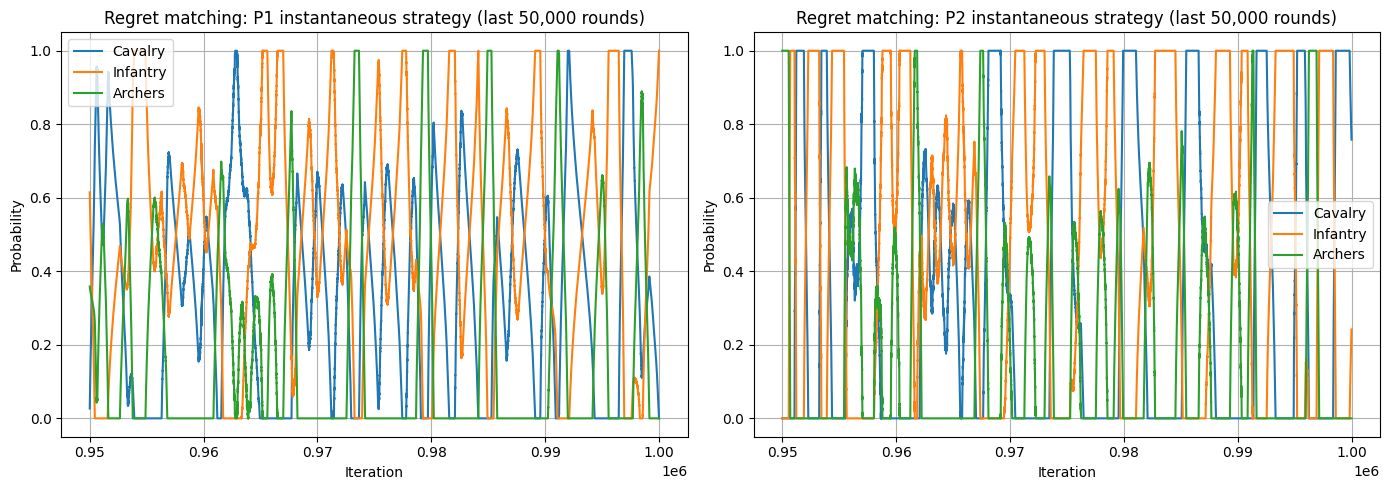

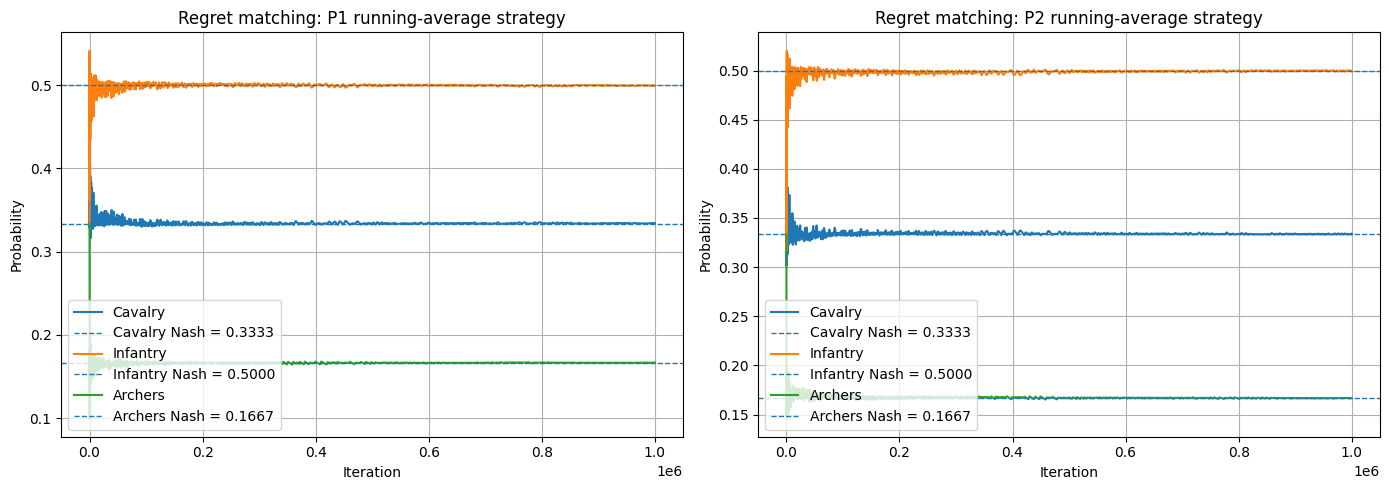

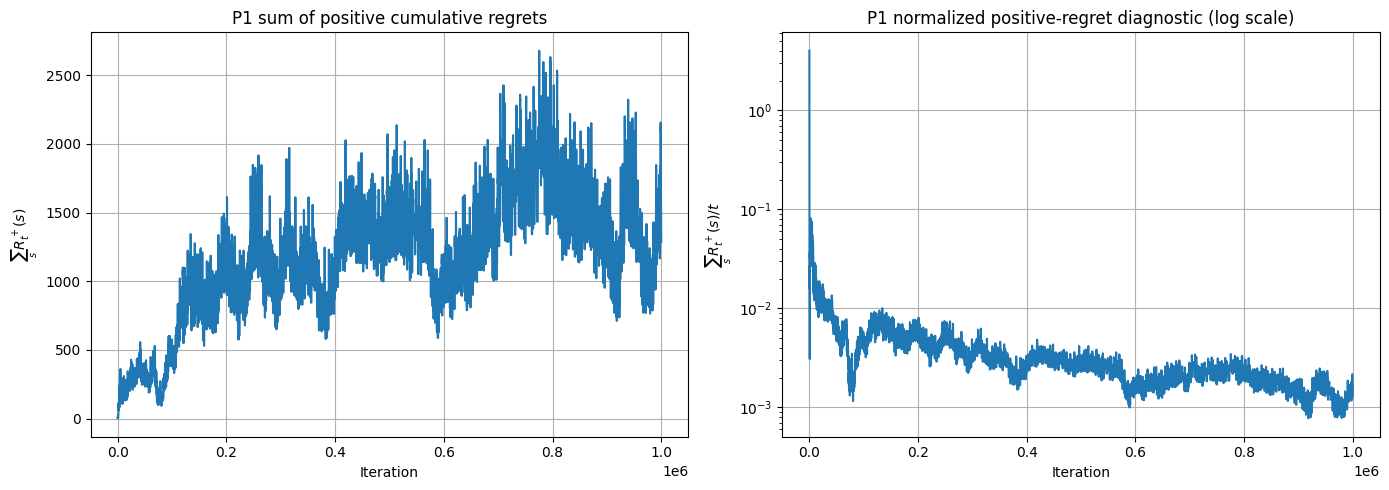

In [5]:
import numpy as np
import matplotlib.pyplot as plt


def _strategy_from_regret(regrets):
    """Regret-matching strategy: normalize positive regret or use uniform."""
    positive = np.maximum(regrets, 0.0)
    total = positive.sum()

    if total <= 0.0:
        return np.full(regrets.size, 1.0 / regrets.size, dtype=float)

    return positive / total


def simulate_regret_matching(A, B, iterations, seed=2026):
    """
    Simulate regret matching for both players in a bimatrix game.

    Returns
    -------
    p1_avg_strat_hist : ndarray, shape (iterations, m)
        Running average of Player 1's instantaneous mixed strategies.
    p1_inst_strat_hist : ndarray, shape (iterations, m)
        Player 1's mixed strategy used at each round.
    p2_avg_strat_hist : ndarray, shape (iterations, n)
        Running average of Player 2's instantaneous mixed strategies.
    p2_inst_strat_hist : ndarray, shape (iterations, n)
        Player 2's mixed strategy used at each round.
    p1_total_regret_hist : ndarray, shape (iterations,)
        Sum of Player 1's positive cumulative regrets after each round.
    """
    A, B = _validate_bimatrix_game(A, B)

    if not isinstance(iterations, (int, np.integer)) or iterations <= 0:
        raise ValueError("iterations must be a positive integer.")

    num_actions_p1, num_actions_p2 = A.shape
    rng = np.random.default_rng(seed)

    p1_inst_strat_hist = np.empty((iterations, num_actions_p1), dtype=float)
    p1_avg_strat_hist = np.empty((iterations, num_actions_p1), dtype=float)
    p2_inst_strat_hist = np.empty((iterations, num_actions_p2), dtype=float)
    p2_avg_strat_hist = np.empty((iterations, num_actions_p2), dtype=float)
    p1_total_regret_hist = np.empty(iterations, dtype=float)

    p1_regrets = np.zeros(num_actions_p1, dtype=float)
    p2_regrets = np.zeros(num_actions_p2, dtype=float)

    p1_strat_sum = np.zeros(num_actions_p1, dtype=float)
    p2_strat_sum = np.zeros(num_actions_p2, dtype=float)

    for t in range(iterations):
        # 1) Convert positive cumulative regrets into valid mixed strategies.
        p1_strategy = _strategy_from_regret(p1_regrets)
        p2_strategy = _strategy_from_regret(p2_regrets)

        # 2) Record instantaneous strategies and sample realized actions.
        p1_inst_strat_hist[t] = p1_strategy
        p2_inst_strat_hist[t] = p2_strategy

        p1_action = int(rng.choice(num_actions_p1, p=p1_strategy))
        p2_action = int(rng.choice(num_actions_p2, p=p2_strategy))

        # 3) Counterfactual regret update for every action, using the action
        #    actually taken by the opponent.
        p1_actual_payoff = A[p1_action, p2_action]
        p2_actual_payoff = B[p1_action, p2_action]

        p1_counterfactual_payoffs = A[:, p2_action]
        p2_counterfactual_payoffs = B[p1_action, :]

        p1_regrets += p1_counterfactual_payoffs - p1_actual_payoff
        p2_regrets += p2_counterfactual_payoffs - p2_actual_payoff

        # 4) Running-average mixed strategies and regret diagnostics.
        p1_strat_sum += p1_strategy
        p2_strat_sum += p2_strategy

        inv_rounds = 1.0 / (t + 1)
        p1_avg_strat_hist[t] = p1_strat_sum * inv_rounds
        p2_avg_strat_hist[t] = p2_strat_sum * inv_rounds

        p1_total_regret_hist[t] = np.maximum(p1_regrets, 0.0).sum()

    assert np.allclose(p1_inst_strat_hist.sum(axis=1), 1.0)
    assert np.allclose(p2_inst_strat_hist.sum(axis=1), 1.0)

    return (
        p1_avg_strat_hist,
        p1_inst_strat_hist,
        p2_avg_strat_hist,
        p2_inst_strat_hist,
        p1_total_regret_hist,
    )


# ==========================================
# RUN REGRET MATCHING ON THE MODIFIED GAME
# ==========================================
regret_iterations = 1_000_000

print("Running regret matching on the modified game...")
(
    p1_avg_strat_hist_rm,
    p1_inst_strat_hist_rm,
    p2_avg_strat_hist_rm,
    p2_inst_strat_hist_rm,
    p1_total_regret_hist_rm,
) = simulate_regret_matching(
    A_mod, B_mod, regret_iterations, seed=2026
)

idx = _plot_indices(regret_iterations)

# Instantaneous strategies can keep oscillating even when running averages
# stabilize. A tail-window view is much more diagnostic than plotting one
# million instantaneous points at once.
inst_tail_window = min(50_000, regret_iterations)
inst_start = regret_iterations - inst_tail_window
inst_idx = np.arange(inst_start, regret_iterations)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for a, name in enumerate(ACTION_NAMES):
    axes[0].plot(inst_idx, p1_inst_strat_hist_rm[inst_idx, a], label=name)
axes[0].set_title(
    f"Regret matching: P1 instantaneous strategy (last {inst_tail_window:,} rounds)"
)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Probability")
axes[0].grid(True)
axes[0].legend()

for a, name in enumerate(ACTION_NAMES):
    axes[1].plot(inst_idx, p2_inst_strat_hist_rm[inst_idx, a], label=name)
axes[1].set_title(
    f"Regret matching: P2 instantaneous strategy (last {inst_tail_window:,} rounds)"
)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Probability")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


# Running-average strategies with Nash reference lines.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for a, name in enumerate(ACTION_NAMES):
    axes[0].plot(idx, p1_avg_strat_hist_rm[idx, a], label=name)
    axes[0].axhline(
        nash_mod[a], linestyle="--", linewidth=1,
        label=f"{name} Nash = {nash_mod[a]:.4f}"
    )
axes[0].set_title("Regret matching: P1 running-average strategy")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Probability")
axes[0].grid(True)
axes[0].legend()

for a, name in enumerate(ACTION_NAMES):
    axes[1].plot(idx, p2_avg_strat_hist_rm[idx, a], label=name)
    axes[1].axhline(
        nash_mod[a], linestyle="--", linewidth=1,
        label=f"{name} Nash = {nash_mod[a]:.4f}"
    )
axes[1].set_title("Regret matching: P2 running-average strategy")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Probability")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


# Raw cumulative positive regret and its time-normalized diagnostic.
time_index = np.arange(1, regret_iterations + 1, dtype=float)
p1_regret_per_round = p1_total_regret_hist_rm / time_index

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(idx, p1_total_regret_hist_rm[idx])
axes[0].set_title("P1 sum of positive cumulative regrets")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel(r"$\sum_s R_t^+(s)$")
axes[0].grid(True)

# Log scaling exposes the late-time decay instead of letting the first few
# rounds dominate the vertical scale.
axes[1].plot(idx, np.maximum(p1_regret_per_round[idx], 1e-12))
axes[1].set_yscale("log")
axes[1].set_title("P1 normalized positive-regret diagnostic (log scale)")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel(r"$\sum_s R_t^+(s) / t$")
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [6]:
# Quantitative summary for the regret-matching run.
p1_rm_final = p1_avg_strat_hist_rm[-1]
p2_rm_final = p2_avg_strat_hist_rm[-1]

p1_rm_dist = np.linalg.norm(p1_rm_final - nash_mod)
p2_rm_dist = np.linalg.norm(p2_rm_final - nash_mod)

print("Modified-game Nash:", np.array2string(nash_mod, precision=6))
print(
    "P1 final running-average strategy:",
    np.array2string(p1_rm_final, precision=6),
)
print(
    "P2 final running-average strategy:",
    np.array2string(p2_rm_final, precision=6),
)
print(f"P1 final L2 distance to Nash: {p1_rm_dist:.8f}")
print(f"P2 final L2 distance to Nash: {p2_rm_dist:.8f}")
print(
    "P1 final sum of positive cumulative regrets:",
    f"{p1_total_regret_hist_rm[-1]:.8f}",
)
print(
    "P1 final normalized positive-regret diagnostic:",
    f"{p1_regret_per_round[-1]:.10f}",
)

# Optional tail statistic for the instantaneous strategies.
rm_tail = min(100_000, regret_iterations)
print(
    f"P1 mean instantaneous strategy over last {rm_tail:,} rounds:",
    np.array2string(
        p1_inst_strat_hist_rm[-rm_tail:].mean(axis=0), precision=6
    ),
)
print(
    f"P2 mean instantaneous strategy over last {rm_tail:,} rounds:",
    np.array2string(
        p2_inst_strat_hist_rm[-rm_tail:].mean(axis=0), precision=6
    ),
)


Modified-game Nash: [0.333333 0.5      0.166667]
P1 final running-average strategy: [0.334229 0.499081 0.16669 ]
P2 final running-average strategy: [0.334073 0.49932  0.166607]
P1 final L2 distance to Nash: 0.00128358
P2 final L2 distance to Nash: 0.00100631
P1 final sum of positive cumulative regrets: 1241.00000000
P1 final normalized positive-regret diagnostic: 0.0012410000
P1 mean instantaneous strategy over last 100,000 rounds: [0.338238 0.492786 0.168976]
P2 mean instantaneous strategy over last 100,000 rounds: [0.332415 0.500337 0.167248]


## Question 1: Mixed-Strategy Nash Equilibria

This has been answered at the beginning of the notebook as well.
Let Player 2 use the mixed strategy

$$
q=(q_C,q_I,q_A).
$$

### Standard game

For Player 1, the expected payoff of each pure action is

$$
u_C=-q_I+q_A,
$$

$$
u_I=q_C-q_A,
$$

$$
u_A=-q_C+q_I.
$$

At a fully mixed Nash equilibrium, Player 1 must be indifferent between all three actions:

$$
-q_I+q_A=q_C-q_A=-q_C+q_I,
$$

together with

$$
q_C+q_I+q_A=1.
$$

Solving gives

$$
q_C=q_I=q_A=\frac{1}{3}.
$$

By symmetry, Player 1 has the same equilibrium strategy. Therefore,

$$
p^*=q^*=
\left(
\frac{1}{3},
\frac{1}{3},
\frac{1}{3}
\right).
$$

Against this strategy, every pure action gives expected payoff zero. Therefore, neither player can improve by a pure unilateral deviation, and the game value is

$$
v=0.
$$

### Modified game

For the modified payoff matrix, Player 1's pure-action expected payoffs are

$$
u_C=-q_I+3q_A,
$$

$$
u_I=q_C-2q_A,
$$

$$
u_A=-3q_C+2q_I.
$$

At equilibrium these values must be equal. Since the equilibrium value is zero,

$$
-q_I+3q_A=0,
$$

$$
q_C-2q_A=0,
$$

$$
-3q_C+2q_I=0.
$$

Therefore,

$$
q_I=3q_A,
\qquad
q_C=2q_A.
$$

Using

$$
q_C+q_I+q_A=1,
$$

we get

$$
2q_A+3q_A+q_A=1,
$$

so

$$
q_A=\frac{1}{6},
\qquad
q_C=\frac{1}{3},
\qquad
q_I=\frac{1}{2}.
$$

Thus, for both players,

$$
p^*=q^*=
\left(
\frac{1}{3},
\frac{1}{2},
\frac{1}{6}
\right),
$$

and the game value is

$$
v=0.
$$

Again, every pure action gives the same expected payoff, so no pure unilateral deviation is profitable.

Changing the payoff magnitudes changes the indifference equations. Therefore, even though the cyclic win/loss ordering stays the same, different probabilities are needed to make the opponent indifferent. This is why the modified game has a different mixed Nash equilibrium.


## Question 2: Convergence, Exploration, and Regret

### 1. Different notions of convergence

The action selected at a particular round does **not** converge. The players keep changing actions because of the cyclic best-response structure. The instantaneous mixed strategy can also continue to oscillate.

What converges much more clearly is the **empirical average strategy**. After one million rounds of ordinary fictitious play, the modified-game strategies were

$$
P_1=(0.332902,\;0.499847,\;0.167251),
$$

$$
P_2=(0.333284,\;0.499733,\;0.166983).
$$

The theoretical Nash equilibrium is

$$
p^*=(0.333333,\;0.500000,\;0.166667).
$$

The final Euclidean distances were

$$
\|P_1-p^*\|_2=0.000742,
$$

and

$$
\|P_2-p^*\|_2=0.000417.
$$

So the empirical frequencies are very close to Nash. The plots also show early oscillations that gradually become smaller.

For regret matching, the instantaneous strategies still change, but the running-average strategies become close to equilibrium. At the end,

$$
\bar p_1=(0.334229,\;0.499081,\;0.166690),
$$

$$
\bar p_2=(0.334073,\;0.499320,\;0.166607).
$$

Their distances from Nash were approximately

$$
0.001284
$$

and

$$
0.001006.
$$

So in both fictitious play and regret matching, the main convergence is in the **empirical or running-average strategy**, not in the individual action at every round.

### 2. Effect of exploration

Increasing epsilon adds more random actions, so the transient learning becomes noisier. However, after one million rounds, all three runs are still close to the unperturbed Nash equilibrium.

The final distances were:

| epsilon | P1 distance | P2 distance |
|---|---:|---:|
| 0.01 | 0.001822 | 0.000565 |
| 0.10 | 0.002399 | 0.001268 |
| 0.30 | 0.001515 | 0.000801 |

Therefore, in these runs the distance to Nash does not change monotonically with epsilon.

The realized payoff variances over the last 100,000 rounds were approximately

$$
2.2798,\qquad 2.0965,\qquad 2.0302
$$

for

$$
\epsilon=0.01,\qquad 0.10,\qquad 0.30,
$$

respectively. So in these particular runs, the realized payoff variance decreased slightly as epsilon increased.

If the exploitative part settles on a fixed distribution

$$
x,
$$

then the epsilon-greedy action distribution is

$$
p_\epsilon
=
(1-\epsilon)x
+
\epsilon
\left(
\frac{1}{3},
\frac{1}{3},
\frac{1}{3}
\right).
$$

Thus, exploration pulls the played distribution toward the uniform distribution.

### 3. Regret matching and no-regret behavior

The regret-matching run gives evidence of no-regret learning.

The final sum of Player 1's positive cumulative regrets was

$$
1241.
$$

This quantity does not have to decrease with time. The important quantity is regret normalized by the number of rounds:

$$
\frac{1241}{10^6}=0.001241.
$$

This is very close to zero, so the average regret per round is small.

The plots also show that the instantaneous strategy keeps oscillating, while the running-average strategy approaches the Nash equilibrium. Therefore, regret matching does not require the instantaneous strategy to converge. The important signs of no-regret behavior are that the normalized regret becomes small and that the average strategy approaches equilibrium.
